# Category Intelligence — Retail Product Performance EDA

**Calibo AI Academy**
**Phase 1 — Mini Use Case 01**
**Industry:** Retail / E-commerce

**Team:** Varshitha, Chandu, Lohitha, Varshini
**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

---
This notebook analyzes six months (January–June 2026) of retail transaction data across five product
categories — Electronics, Apparel, Grocery, Home & Kitchen, and Personal Care — to prepare the
Category Manager for a quarterly supplier review.


## CBIM Problem Canvas

**1. Situation (S)**
The retail chain sells products across five categories (Electronics, Apparel, Grocery, Home &
Kitchen, Personal Care) through multiple stores. Six months of transaction-level sales data
(Jan–Jun 2026) is available, capturing revenue, units sold, unit price, and discount percentage for
every transaction.

**2. Complication (C)**
The Category Manager must decide, ahead of a quarterly supplier review, which categories deserve more
investment, which should be challenged, and whether the current discounting strategy is worth its
revenue cost — without any product cost or margin data to lean on.

**3. Question (Q)**
Which categories/products are growing or declining and by how much, which products should be
challenged with suppliers, and is discounting generating a meaningful revenue return?

**4. SSOT**
`MUC01_Retail_Sales_Dataset.csv`

**5. Success Definition**
A data-backed recommendation the Category Manager can bring into the supplier review: one category to
back, one to challenge, a clear read on discount effectiveness, and one specific timing insight —
each backed by an actual figure from the dataset.

**6. Primary Stakeholder**
Category Manager


## Import Libraries

In [1]:
# Import the libraries needed for data handling, math, and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean grid style and a readable default figure size for every chart.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Show large numbers with thousands separators instead of scientific notation.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## Load and Inspect Data

The dataset is loaded from a relative path so this notebook runs on any machine as long as
`MUC01_Retail_Sales_Dataset.csv` sits in the same project folder.

**Owner: Varshitha**

Before any analysis, we load the retail transaction dataset and check its shape, data types,
completeness, and basic structure. This confirms the data is reliable enough to base business
conclusions on.


In [2]:
# Load the retail sales dataset from the project folder (relative path).
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
print(df.head())


  transaction_id        date store_id  ... unit_price   revenue discount_pct
0      TXN000001  2026-01-01      S01  ...   3,075.46  5,843.37            5
1      TXN000002  2026-01-01      S01  ...  11,598.06 11,598.06            0
2      TXN000003  2026-01-01      S01  ...   5,738.37 15,493.60           10
3      TXN000004  2026-01-01      S01  ...   3,281.28  9,351.65            5
4      TXN000005  2026-01-01      S01  ...   1,917.14  1,917.14            0

[5 rows x 10 columns]


In [3]:
# Check row/column count to confirm the full dataset loaded.
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (107836, 10)


**Business read:** the dataset contains just under 108,000 individual sales transactions
across six months — enough volume to draw reliable category- and product-level conclusions.

In [4]:
# Check column data types to catch anything loaded in the wrong format.
df.dtypes


In [5]:
# Get a structural summary: column count, non-null counts, and memory usage.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  str    
 1   date            107836 non-null  str    
 2   store_id        107836 non-null  str    
 3   store_city      107836 non-null  str    
 4   category        107836 non-null  str    
 5   product_name    107836 non-null  str    
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 8.2 MB


**Data quality check:** `date` currently loads as text, not a true date — this needs to
be converted before any time-based analysis (monthly trend, day-of-week pattern) will work correctly.

In [6]:
# Count missing values in every column.
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64


**Business read:** there are no missing values in any column — the dataset is complete
and usable as-is.

In [7]:
# Check for fully duplicated rows, which would double-count revenue if present.
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


**Business read:** there are no duplicate transactions, so revenue totals will not be
inflated by double-counted rows.

In [8]:
# Get summary statistics for all numeric columns (min, max, mean, spread).
df.describe()


**Business read:** unit prices and discount levels span a wide but sensible range, and
there are no negative revenue or negative unit values — an early sign the data does not contain
obvious entry errors.

In [9]:
# Count distinct products and categories, and list the categories present.
print("Unique products:", df["product_name"].nunique())
print("Unique categories:", df["category"].nunique())
print("Categories:", sorted(df["category"].unique()))


Unique products: 25
Unique categories: 5
Categories: ['Apparel', 'Electronics', 'Grocery', 'Home & Kitchen', 'Personal Care']


**Business read:** the data covers the expected 5 categories, each with 5 distinct
products (25 products total) — matching the structure the Category Manager works with.

In [10]:
# Convert the date column into a true datetime type so later steps can use it.
df["date"] = pd.to_datetime(df["date"])
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("date column dtype after conversion:", df["date"].dtype)


Date range: 2026-01-01 to 2026-06-30
date column dtype after conversion: datetime64[us]


**Data quality note:** `date` is now a proper datetime column, confirmed to span the
full Jan 1 – Jun 30, 2026 window described in the project brief.

### Business Interpretation
The dataset is complete, duplicate-free, and structurally sound: ~107,836 transactions across the
full 6-month window, 5 categories, 25 products, no missing values, and no obviously invalid entries.
This is a reliable foundation for the revenue, product, discount, and timing analysis that follows.

## Step 2 — Category Revenue Trend
**Owner: Chandu**

We look at how monthly revenue for each of the five categories has moved over the six-month window,
to see which categories are growing, declining, or holding steady.


In [11]:
# Extract a "YYYY-MM" month label from each transaction date.
df["month"] = df["date"].dt.to_period("M").astype(str)

# Sum revenue by month and category, then reshape so each category is its own column.
cat_month_revenue = (
    df.groupby(["month", "category"])["revenue"]
    .sum()
    .reset_index()
    .pivot(index="month", columns="category", values="revenue")
)
cat_month_revenue


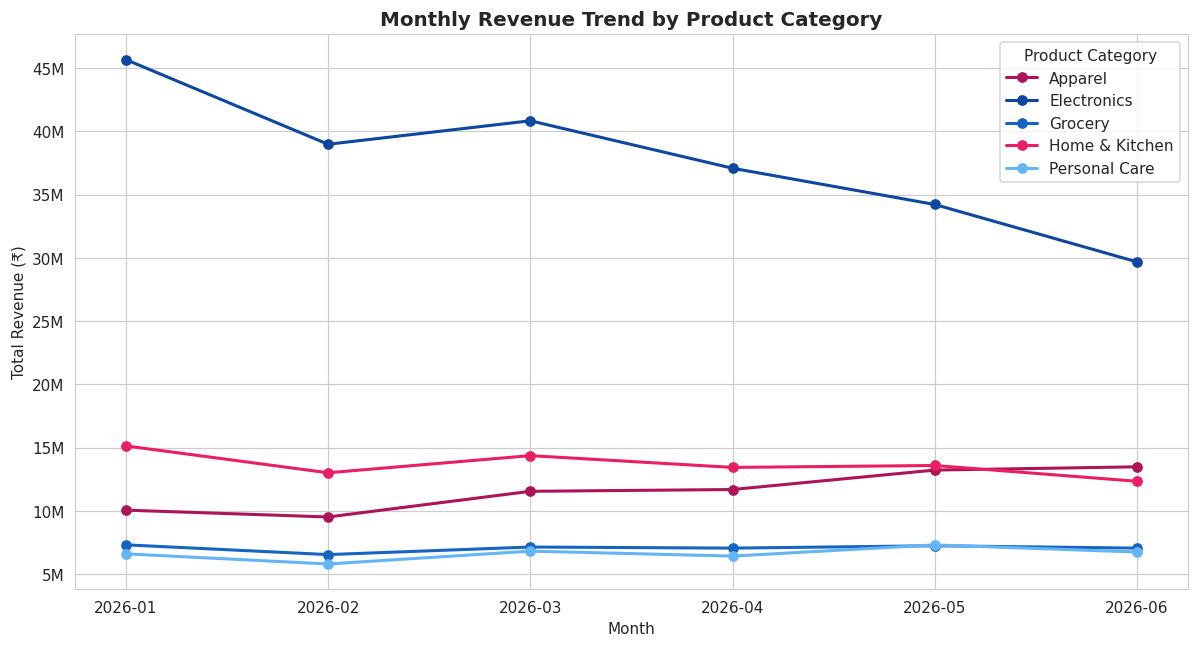

In [12]:
# Line chart of monthly revenue for all five categories (pink + blue only).
CAT_COLORS = {
    "Electronics": "#0d47a1",
    "Apparel": "#ad1457",
    "Grocery": "#1565c0",
    "Home & Kitchen": "#e91e63",
    "Personal Care": "#64b5f6",
}

fig, ax = plt.subplots(figsize=(11, 6))
for category in cat_month_revenue.columns:
    ax.plot(cat_month_revenue.index, cat_month_revenue[category], marker="o", linewidth=2,
            label=category, color=CAT_COLORS.get(category))

ax.set_title("Monthly Revenue Trend by Product Category")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (\u20b9)")
ax.legend(title="Product Category", loc="upper right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout()
plt.show()


In [13]:
# Compute percent change Jan -> Jun, consistency (coefficient of variation), and total revenue.
first_month = cat_month_revenue.iloc[0]
last_month = cat_month_revenue.iloc[-1]
pct_change = ((last_month - first_month) / first_month * 100).sort_values()

cv = (cat_month_revenue.std() / cat_month_revenue.mean()).sort_values()

total_revenue_by_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

print("Percent change in monthly revenue, Jan -> Jun 2026 (most negative = biggest decline):")
print(pct_change.round(2))
print()
print("Coefficient of variation across the 6 months (lower = more consistent):")
print(cv.round(2))
print()
print("Total 6-month revenue by category (overall scale):")
print(total_revenue_by_category.round(2))
print()
print(f"Declined the most: {pct_change.index[0]} ({pct_change.iloc[0]:.1f}%)")
print(f"Most consistent: {cv.index[0]} (CV = {cv.iloc[0]:.3f})")
print(f"Strongest growth: {pct_change.index[-1]} ({pct_change.iloc[-1]:.1f}%)")


Percent change in monthly revenue, Jan -> Jun 2026 (most negative = biggest decline):
category
Electronics      -35.02
Home & Kitchen   -18.49
Grocery           -3.55
Personal Care      2.18
Apparel           34.10
dtype: float64

Coefficient of variation across the 6 months (lower = more consistent):
category
Grocery          0.04
Home & Kitchen   0.07
Personal Care    0.08
Apparel          0.14
Electronics      0.15
dtype: float64

Total 6-month revenue by category (overall scale):
category
Electronics      226,527,724.93
Home & Kitchen    81,845,721.33
Apparel           69,479,589.68
Grocery           42,302,580.76
Personal Care     39,648,560.08
Name: revenue, dtype: float64

Declined the most: Electronics (-35.0%)
Most consistent: Grocery (CV = 0.039)
Strongest growth: Apparel (34.1%)


### Business Interpretation
**Electronics fell the most** — its monthly revenue dropped sharply from January to June 2026, and it
is also the least consistent of the five categories month-to-month. This matters a great deal because
Electronics is still by far the *largest* category by total revenue, so a sustained decline of this
size represents a large absolute loss for the business, not a rounding error.

**Apparel is the clear growth story** — it is the only category with sustained month-over-month
growth across the full window, making it the strongest candidate for expanded shelf space and
supplier investment. **Grocery is the most stable** category, moving least from month to month, while
Home & Kitchen and Personal Care sit in between — roughly flat to mildly declining.

For the Category Manager, this points to two clear conversations: challenging Electronics suppliers on
the sharp decline, and backing Apparel suppliers with more confidence given its consistent growth.

## Step 3 — Top and Bottom Products by Category
**Owner: Lohitha**

For every category, we rank products by total 6-month revenue and identify the top 2 and bottom 2
performers, to see which specific products are driving or dragging category results.


In [14]:
# For each category, rank its 5 products by total revenue and keep the top 2 / bottom 2.
rows = []
for category in sorted(df["category"].unique()):
    prod_rev = (
        df[df["category"] == category]
        .groupby("product_name")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )
    top2 = prod_rev.head(2)
    bottom2 = prod_rev.tail(2)
    for product, revenue in top2.items():
        rows.append({"Category": category, "Rank Type": "Top", "Product": product, "Total Revenue": revenue})
    for product, revenue in bottom2.items():
        rows.append({"Category": category, "Rank Type": "Bottom", "Product": product, "Total Revenue": revenue})

top_bottom_summary = pd.DataFrame(rows)
top_bottom_summary


In [15]:
# Across every category, which specific products are the weakest overall?
weakest_products = top_bottom_summary[top_bottom_summary["Rank Type"] == "Bottom"].sort_values("Total Revenue")
print("Lowest-revenue products overall (across all categories):")
print(weakest_products.head(5).to_string(index=False))


Lowest-revenue products overall (across all categories):
     Category Rank Type     Product  Total Revenue
Personal Care    Bottom   Sunscreen   7,593,863.45
Personal Care    Bottom  Toothpaste   7,768,812.48
      Grocery    Bottom Sugar (1kg)   8,377,786.05
      Grocery    Bottom    Oil (1L)   8,431,630.01
      Apparel    Bottom       Kurta  13,606,747.03


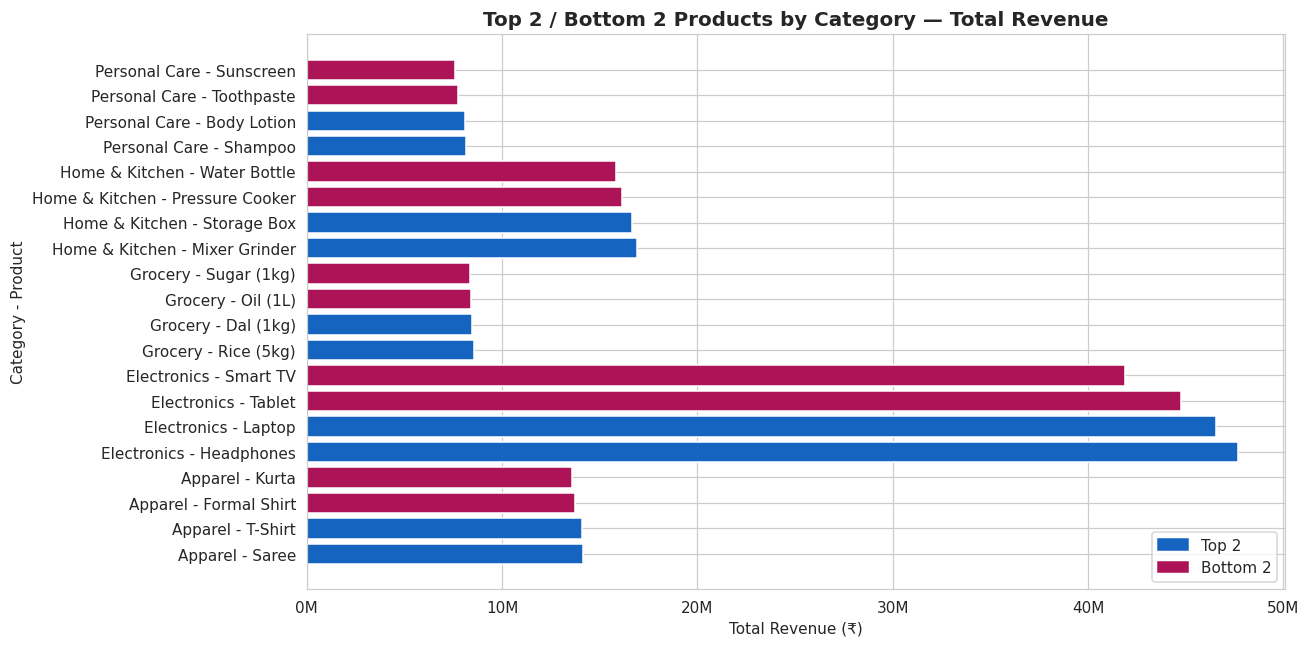

In [16]:
# Chart: total revenue for the top 2 / bottom 2 products in each category (pink + blue only).
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = top_bottom_summary.copy()
plot_df["label"] = plot_df["Category"] + " - " + plot_df["Product"]
colors = plot_df["Rank Type"].map({"Top": "#1565c0", "Bottom": "#ad1457"})
ax.barh(plot_df["label"], plot_df["Total Revenue"], color=colors)
ax.set_title("Top 2 / Bottom 2 Products by Category — Total Revenue")
ax.set_xlabel("Total Revenue (\u20b9)")
ax.set_ylabel("Category - Product")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#1565c0", label="Top 2"), Patch(color="#ad1457", label="Bottom 2")], loc="lower right")
plt.tight_layout()
plt.show()


### Business Interpretation
Within every category, revenue is fairly evenly spread across its five products — there is no single
product collapsing on its own inside a category. That means the **Electronics decline (from Step 2)
is a category-wide problem, not a single weak SKU**: its softest performers contribute to the drop,
but so does every other product in the category.

The weakest individual products chain-wide sit mainly in **Personal Care and Grocery** — categories
that are already low-revenue overall, so their bottom performers are a lower business priority than
Electronics' decline. For the supplier review, the most useful product-level detail to raise is which
specific Electronics products are softest, since that category is where the revenue is actually at
stake.

## Step 4 — Discount Effectiveness
**Owner: Varshitha**

We group transactions into discount brackets and compare average revenue per transaction and
average units sold across brackets, using the actual `discount_pct` values present in the data.


In [17]:
# List the distinct discount percentages that actually occur in the data.
print("Distinct discount_pct values in the data:", sorted(df["discount_pct"].unique()))


Distinct discount_pct values in the data: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]


In [18]:
# Bucket every transaction into a discount bracket.
bracket_edges = [-1, 0, 5, 10, 15, 20, 100]
bracket_labels = ["0%", "5%", "10%", "15%", "20%", "25%+"]
df["discount_bracket"] = pd.cut(df["discount_pct"], bins=bracket_edges, labels=bracket_labels)

# For each bracket, compute transaction count, average revenue/txn, and average units/txn.
discount_summary = df.groupby("discount_bracket", observed=False).agg(
    num_transactions=("transaction_id", "count"),
    avg_revenue_per_transaction=("revenue", "mean"),
    avg_units_sold=("units_sold", "mean"),
)
print(discount_summary)


                  num_transactions  avg_revenue_per_transaction  avg_units_sold
discount_bracket                                                               
0%                           36033                     4,685.65            2.59
5%                           23922                     4,303.73            2.59
10%                          23810                     4,005.55            2.57
15%                          11935                     4,069.16            2.60
20%                          12136                     3,631.73            2.58
25%+                             0                          NaN             NaN


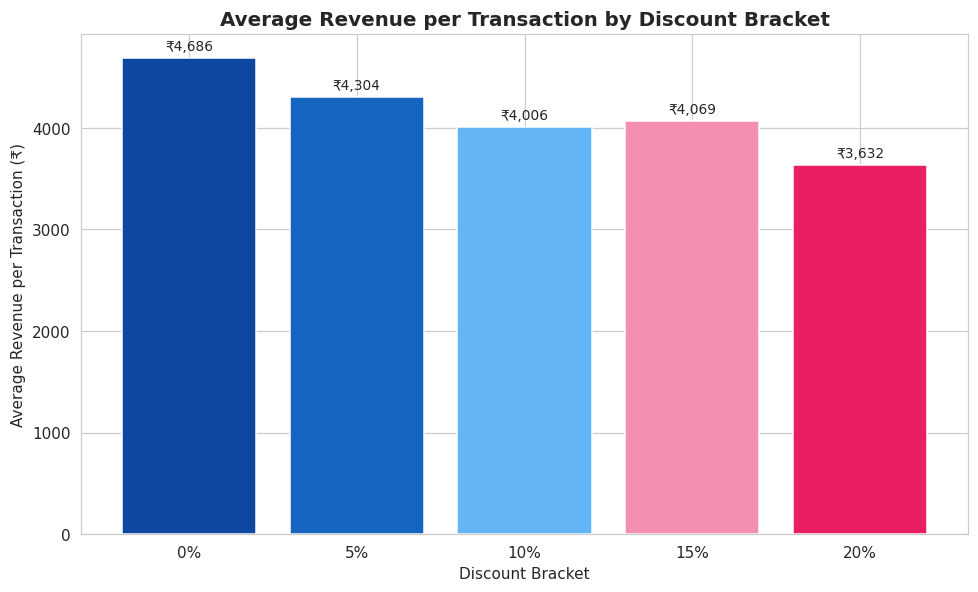

In [19]:
# Bar chart of average revenue per transaction by discount bracket (pink + blue only).
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#0d47a1", "#1565c0", "#64b5f6", "#f48fb1", "#e91e63", "#ad1457"]
bars = ax.bar(discount_summary.index.astype(str), discount_summary["avg_revenue_per_transaction"], color=colors[:len(discount_summary)])

ax.set_title("Average Revenue per Transaction by Discount Bracket")
ax.set_xlabel("Discount Bracket")
ax.set_ylabel("Average Revenue per Transaction (\u20b9)")
for bar in bars:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f"\u20b9{height:,.0f}", (bar.get_x() + bar.get_width() / 2, height),
                    textcoords="offset points", xytext=(0, 5), ha="center", fontsize=9)
plt.tight_layout()
plt.show()


In [20]:
# Pull out the headline comparison numbers for the write-up below.
valid = discount_summary.dropna()
best_bracket = valid["avg_revenue_per_transaction"].idxmax()
worst_bracket = valid["avg_revenue_per_transaction"].idxmin()
zero_disc = valid.loc["0%", "avg_revenue_per_transaction"]
top_disc_bracket = valid.index[-1]
top_disc_value = valid.loc[top_disc_bracket, "avg_revenue_per_transaction"]
pct_change_disc = (top_disc_value - zero_disc) / zero_disc * 100
avg_units_range = (valid["avg_units_sold"].min(), valid["avg_units_sold"].max())

print(f"Highest avg revenue/txn: {best_bracket} bracket (\u20b9{valid['avg_revenue_per_transaction'].max():,.0f})")
print(f"Lowest avg revenue/txn: {worst_bracket} bracket (\u20b9{valid['avg_revenue_per_transaction'].min():,.0f})")
print(f"0% discount avg revenue/txn: \u20b9{zero_disc:,.0f}")
print(f"Highest discount bracket present ({top_disc_bracket}) avg revenue/txn: \u20b9{top_disc_value:,.0f}")
print(f"Change vs 0% bracket: {pct_change_disc:.1f}%")
print(f"Average units sold per transaction ranges: {avg_units_range[0]:.2f} to {avg_units_range[1]:.2f}")
if discount_summary["num_transactions"].isna().any() or (discount_summary["num_transactions"] == 0).any():
    print("\nNote: the '25%+' bracket has no transactions in the data, so it is shown as unavailable.")


Highest avg revenue/txn: 0% bracket (₹4,686)
Lowest avg revenue/txn: 20% bracket (₹3,632)
0% discount avg revenue/txn: ₹4,686
Highest discount bracket present (20%) avg revenue/txn: ₹3,632
Change vs 0% bracket: -22.5%
Average units sold per transaction ranges: 2.57 to 2.60

Note: the '25%+' bracket has no transactions in the data, so it is shown as unavailable.


### Business Interpretation
The pattern runs in the opposite direction of a "discounts drive bigger baskets" story. Average
revenue per transaction is highest with **no discount at all (0%)** and steadily *decreases* as the
discount level rises. Average units sold per transaction stays essentially flat across every bracket
— customers are not buying meaningfully more per transaction at deeper discounts, they are simply
paying less. No transactions in the data carry a discount of 25% or higher, so that bracket is shown
as unavailable rather than estimated.

**Revenue data alone cannot directly measure margin or profitability** — the dataset has no product
cost field, so this finding is about revenue collected per transaction, not profit. It is still a
reasonable basis to question whether current discount depth is paying for itself in volume terms, and
worth revisiting with suppliers who help fund promotional discount campaigns.

## Step 5 — Day-of-Week and Monthly Patterns
**Owner: Varshini**

We look at when revenue is strongest during the week and across the six months, to inform when
promotions and supplier-funded campaigns should be timed.


In [21]:
# Extract the day name for every transaction and set a Mon-Sun display order.
df["day_of_week"] = df["date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_daily_revenue_by_weekday = (
    df.groupby("day_of_week")["revenue"].mean().reindex(weekday_order)
)
avg_daily_revenue_by_weekday


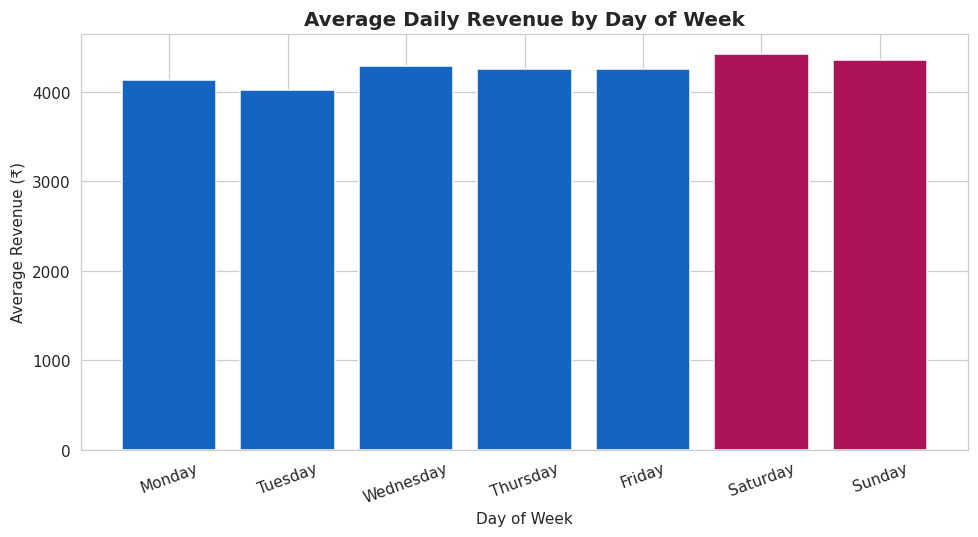

In [22]:
# Bar chart of average revenue per transaction by day of week (pink + blue only).
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#ad1457" if day in ("Saturday", "Sunday") else "#1565c0" for day in weekday_order]
ax.bar(weekday_order, avg_daily_revenue_by_weekday.values, color=colors)
ax.set_title("Average Daily Revenue by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Revenue (\u20b9)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [23]:
# Total revenue by month, across the full 6-month window.
monthly_total_revenue = df.groupby("month")["revenue"].sum()
monthly_total_revenue


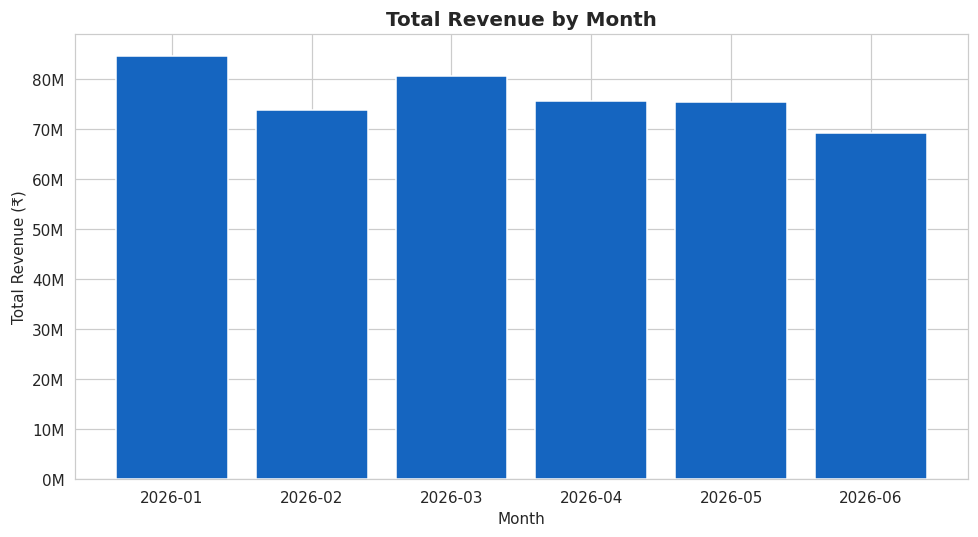

In [24]:
# Bar chart of total revenue by month (pink + blue only).
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(monthly_total_revenue.index, monthly_total_revenue.values, color="#1565c0")
ax.set_title("Total Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (\u20b9)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout()
plt.show()


In [25]:
# Identify best/worst day and month, and Electronics' monthly share of total revenue.
best_day = avg_daily_revenue_by_weekday.idxmax()
worst_day = avg_daily_revenue_by_weekday.idxmin()
best_month = monthly_total_revenue.idxmax()
worst_month = monthly_total_revenue.idxmin()

print(f"Best day (avg revenue/transaction): {best_day} (\u20b9{avg_daily_revenue_by_weekday.max():,.0f})")
print(f"Worst day (avg revenue/transaction): {worst_day} (\u20b9{avg_daily_revenue_by_weekday.min():,.0f})")
print(f"Best month (total revenue): {best_month} (\u20b9{monthly_total_revenue.max():,.0f})")
print(f"Worst month (total revenue): {worst_month} (\u20b9{monthly_total_revenue.min():,.0f})")

electronics_share_by_month = (
    df[df["category"] == "Electronics"].groupby("month")["revenue"].sum() / monthly_total_revenue * 100
)
print()
print("Electronics share of total monthly revenue:")
print(electronics_share_by_month.round(1))


Best day (avg revenue/transaction): Saturday (₹4,420)
Worst day (avg revenue/transaction): Tuesday (₹4,018)
Best month (total revenue): 2026-01 (₹84,768,131)
Worst month (total revenue): 2026-06 (₹69,282,134)

Electronics share of total monthly revenue:
month
2026-01   53.90
2026-02   52.80
2026-03   50.60
2026-04   49.00
2026-05   45.30
2026-06   42.80
Name: revenue, dtype: float64


### Business Interpretation
**Saturday and Sunday are the strongest days**, both in total weekend revenue and in average revenue
per transaction, while **Tuesday is consistently the weakest**. This is a normal retail weekly pattern
and suggests promotional pushes and supplier-funded campaigns are best timed to launch just before the
weekend, riding the natural traffic peak rather than mid-week.

**January is the strongest month and June the weakest** — total chain revenue declines steadily across
the window. Tracking Electronics' share of monthly revenue alongside this shows the category's decline
outpacing the overall chain slowdown: Electronics' share of total revenue drops every single month,
confirming it is not simply following a general seasonal dip but genuinely losing ground relative to
the rest of the business.

## Step 6 — Category Manager Briefing
**Owners: All Members (Varshitha, Chandu, Lohitha, Varshini)**

This section pulls together the findings from Steps 2 through 5 into the briefing the Category
Manager will actually use in the supplier review.


# Category Manager Briefing

**Apparel has the strongest case for increased supplier investment** (Step 2): it grew
approximately 34.1% in monthly revenue from January to June 2026, the only category with
sustained growth over the window, making it the clear candidate for expanded shelf space and
supplier commitments.

**Electronics should be challenged in the supplier review**: its monthly revenue fell approximately
35.0% over the same period, on total 6-month revenue of roughly ₹226,527,725
(Step 2) — the largest single driver of the chain's overall slowdown, spread across the category
rather than concentrated in one product (Step 3).

**Discounting is not paying for itself in volume terms** (Step 4): average revenue per transaction
fell from ₹4,686 at 0% discount to ₹3,632 at the deepest bracket present
in the data (a -22.5% drop), while average units sold per transaction stayed essentially
flat — deeper discounts are reducing revenue collected without a matching increase in basket size.

**Promotions should be timed around the weekend** (Step 5): Saturday is the strongest day and
Tuesday the weakest for average revenue per transaction, and January 2026 was the strongest month
chain-wide against June 2026 as the weakest, with Electronics' share of monthly revenue
declining every single month — confirming its decline is outpacing the general trend, not just
following it.

**One additional data point is needed before a final recommendation:** product cost / margin data.
Every finding above is a revenue-side finding; without cost data, none of it can be converted into a
profitability or true ROI conclusion for the supplier conversation.


## Key Findings

**Key Finding 1: Electronics revenue is declining sharply**
- Supporting number: monthly revenue fell approximately 35% from January to June 2026.
- Business implication: Electronics is the single biggest driver of the chain's overall revenue
  slowdown and is the top item to raise with suppliers.

**Key Finding 2: Apparel is the standout growth category**
- Supporting number: monthly revenue grew approximately 34% over the same window, the
  only category with sustained growth.
- Business implication: Apparel is the strongest candidate for expanded shelf space and supplier
  investment.

**Key Finding 3: Deeper discounts do not generate proportionately larger transactions**
- Supporting number: average revenue per transaction dropped from ₹4,686 at 0% discount
  to ₹3,632 at the highest discount bracket present in the data, while average units sold
  stayed roughly flat.
- Business implication: current discount depth should be revisited with suppliers who help fund
  promotional campaigns.


## Limitations

- **No cost or margin data:** the dataset contains revenue, price, and discount fields, but no
  product cost. This means profitability and true margin impact — including of the discount pattern
  in Step 4 — cannot be measured directly, only inferred from revenue trends.
- **Six-month window only:** the analysis covers January–June 2026. Seasonal effects beyond this
  window (e.g. festive-season spikes) cannot be assessed from this data alone.
- **No supplier-level data:** the dataset is transaction-level by product/category, not by supplier,
  so supplier-specific performance is inferred from product performance rather than measured directly.
